Practica 1

(np.float64(-0.5), np.float64(666.5), np.float64(999.5), np.float64(-0.5))

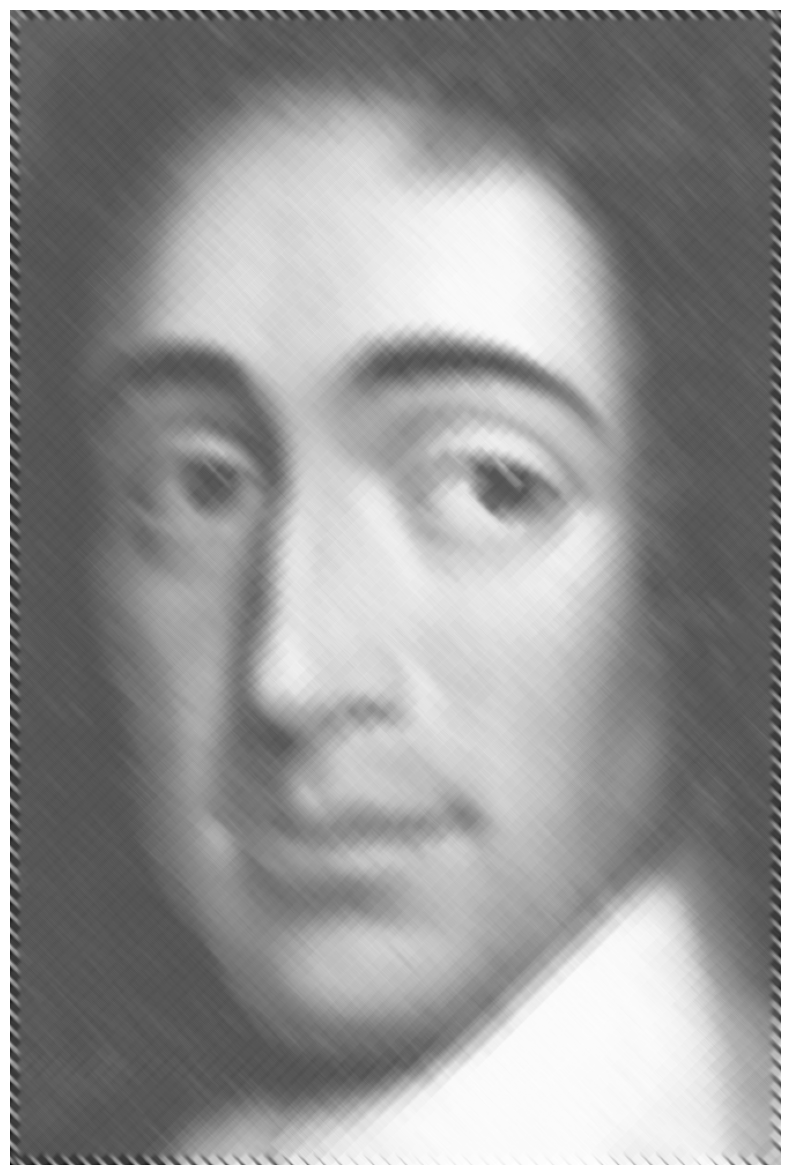

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("Pepe.jpg", cv2.IMREAD_GRAYSCALE)

def kernel_diagonal(t):
    k = np.zeros((t, t), np.float32)
    for i in range(t):
        k[i, i] = 1
    return k / np.sum(k)

def kernel_diagonal_inverso(t):
    k = np.zeros((t, t), np.float32)
    for i in range(t):
        k[i, t - 1 - i] = 1
    return k / np.sum(k)

def kernel_media(t):
    k = np.ones((t, t), np.float32)
    return k / np.sum(k)

def kernel_enfoque():
    return np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32)

def kernel_realce_horizontal():
    return np.array([
        [-1, -1, -1],
        [ 2,  2,  2],
        [-1, -1, -1]
    ], dtype=np.float32)

def kernel_realce_vertical():
    return np.array([
        [-1,  2, -1],
        [-1,  2, -1],
        [-1,  2, -1]
    ], dtype=np.float32)

k1 = kernel_diagonal(21)
k2 = kernel_diagonal_inverso(21)
k3 = kernel_media(5)
k4 = kernel_enfoque()
k5 = kernel_realce_horizontal()
k6 = kernel_realce_vertical()

suave1 = cv2.filter2D(img, -1, k1)
suave2 = cv2.filter2D(img, -1, k2)
mezcla1 = cv2.addWeighted(suave1, 0.5, suave2, 0.5, 0)

suave3 = cv2.filter2D(mezcla1, -1, k3)
realce_h = cv2.filter2D(suave3, -1, k5)
realce_v = cv2.filter2D(suave3, -1, k6)
mezcla2 = cv2.addWeighted(realce_h, 0.5, realce_v, 0.5, 0)

final = cv2.filter2D(mezcla2, -1, k4)

plt.figure(figsize=(30, 15))


plt.imshow(suave1, cmap="gray")
plt.axis("off")





